In [35]:
# =========================
# 1. Imports
# =========================
import re
import json
import random
from pathlib import Path
import os

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

In [36]:
# ================================
# 2. Check folder paths and files
# ================================
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()

RAW_DIR = PROJECT_DIR / "dataset" / "raw"
PROCESSED_DIR = PROJECT_DIR / "dataset" / "processed"

REPORTS_CSV = RAW_DIR / "indiana_reports.csv"
PROJECTIONS_CSV = RAW_DIR / "indiana_projections.csv"
IMAGES_DIR = RAW_DIR / "images" / "images_normalized"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR    :", PROJECT_DIR)
print("RAW_DIR        :", RAW_DIR)
print("PROCESSED_DIR  :", PROCESSED_DIR)
print("REPORTS_CSV    :", REPORTS_CSV.exists(), REPORTS_CSV)
print("PROJECTIONS_CSV:", PROJECTIONS_CSV.exists(), PROJECTIONS_CSV)
print("IMAGES_DIR     :", IMAGES_DIR.exists(), IMAGES_DIR)

PROJECT_DIR    : /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec
RAW_DIR        : /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/raw
PROCESSED_DIR  : /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed
REPORTS_CSV    : True /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/raw/indiana_reports.csv
PROJECTIONS_CSV: True /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/raw/indiana_projections.csv
IMAGES_DIR     : True /Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/raw/images/images_normalized


# Load dataset

In [37]:
# ============================================================
# 3) Load CSV files into dataframe
# ============================================================
reports_df = pd.read_csv(REPORTS_CSV)
projections_df = pd.read_csv(PROJECTIONS_CSV)

print("\nreports_df shape    :", reports_df.shape)
print("projections_df shape:", projections_df.shape)

print("\nreports_df columns:")
print(reports_df.columns.tolist())

print("\nprojections_df columns:")
print(projections_df.columns.tolist())


reports_df shape    : (3851, 8)
projections_df shape: (7466, 3)

reports_df columns:
['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression']

projections_df columns:
['uid', 'filename', 'projection']


In [38]:
reports_df.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [39]:
projections_df.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


# Basic Cleaning

In [40]:
# standardize column names
reports_df.columns = [c.strip().lower() for c in reports_df.columns]
projections_df.columns = [c.strip().lower() for c in projections_df.columns]

# remove duplicate rows if any
reports_df = reports_df.drop_duplicates().copy()
projections_df = projections_df.drop_duplicates().copy()

# make sure uid is numeric where possible
reports_df["uid"] = pd.to_numeric(reports_df["uid"], errors="coerce")
projections_df["uid"] = pd.to_numeric(projections_df["uid"], errors="coerce")

reports_df = reports_df.dropna(subset=["uid"]).copy()
projections_df = projections_df.dropna(subset=["uid"]).copy()

reports_df["uid"] = reports_df["uid"].astype(int)
projections_df["uid"] = projections_df["uid"].astype(int)

print("reports_df shape cleaning:", reports_df.shape)
print("projections_df cleaning:", projections_df.shape)

reports_df shape cleaning: (3851, 8)
projections_df cleaning: (7466, 3)


# Normalize projection label

In [41]:
projections_df['projection'].value_counts()

projection
Frontal    3818
Lateral    3648
Name: count, dtype: int64

In [42]:
def normalize_projection(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    # common variants
    if "frontal" in x:
        return "Frontal"
    if "lateral" in x:
        return "Lateral"
    
    return x.title()

projections_df["projection_clean"] = projections_df["projection"].apply(normalize_projection)

projections_df["projection_clean"].value_counts(dropna=False)

projection_clean
Frontal    3818
Lateral    3648
Name: count, dtype: int64

In [43]:
# ========= keep only usable image files ===============
# build full image path
projections_df["image_path"] = projections_df["filename"].astype(str).apply(lambda x: str(IMAGES_DIR / x))

# mark whether file exists
projections_df["file_exists"] = projections_df["image_path"].apply(os.path.exists)

print(projections_df["file_exists"].value_counts(dropna=False))
projections_df.head()

file_exists
True    7466
Name: count, dtype: int64


,uid,filename,projection,projection_clean,image_path,file_exists
0,1,1_IM-0001-4001.dcm.png,Frontal,Frontal,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,True
1,1,1_IM-0001-3001.dcm.png,Lateral,Lateral,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,True
2,2,2_IM-0652-1001.dcm.png,Frontal,Frontal,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,True
3,2,2_IM-0652-2001.dcm.png,Lateral,Lateral,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,True
4,3,3_IM-1384-1001.dcm.png,Frontal,Frontal,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,True


In [44]:
usable_proj = projections_df[
    projections_df["projection_clean"].isin(["Frontal", "Lateral"]) &
    projections_df["file_exists"]
].copy()

# in case a uid has multiple frontal or lateral files, keep first one
frontal_df = (
    usable_proj[usable_proj["projection_clean"] == "Frontal"]
    .sort_values(["uid", "filename"])
    .drop_duplicates(subset=["uid"], keep="first")
    [["uid", "filename", "image_path"]]
    .rename(columns={
        "filename": "frontal_filename",
        "image_path": "frontal_path"
    })
)

lateral_df = (
    usable_proj[usable_proj["projection_clean"] == "Lateral"]
    .sort_values(["uid", "filename"])
    .drop_duplicates(subset=["uid"], keep="first")
    [["uid", "filename", "image_path"]]
    .rename(columns={
        "filename": "lateral_filename",
        "image_path": "lateral_path"
    })
)

paired_images_df = frontal_df.merge(lateral_df, on="uid", how="inner")

print("paired_images_df shape:", paired_images_df.shape)
paired_images_df.head()

paired_images_df shape: (3388, 5)


,uid,frontal_filename,frontal_path,lateral_filename,lateral_path
0,1,1_IM-0001-4001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,1_IM-0001-3001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
1,2,2_IM-0652-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,2_IM-0652-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
2,3,3_IM-1384-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,3_IM-1384-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
3,4,4_IM-2050-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,4_IM-2050-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
4,5,5_IM-2117-1003002.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,5_IM-2117-1004003.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...


# Text cleaning

In [45]:
def remove_masked_x(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).strip().lower()
    
    # remove standalone masked tokens like x, xx, xxx, xxxx, xxxxx
    text = re.sub(r"\bx+\b", " ", text)
    
    # remove repeated spaces before other cleaning
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def clean_text(text):
    if pd.isna(text):
        return np.nan
    
    text = remove_masked_x(text)
    
    if pd.isna(text) or text == "":
        return np.nan
    
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"[^a-z0-9\s\.,;:\-\(\)/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    if text == "":
        return np.nan
    
    return text

def clean_label_text(text):
    if pd.isna(text):
        return np.nan
    
    text = remove_masked_x(text)
    
    if pd.isna(text) or text == "":
        return np.nan
    
    text = re.sub(r"\s+", " ", text).strip()
    
    if text == "":
        return np.nan
    
    return text

# Process report columns

In [46]:
text_cols = ["mesh", "problems", "image", "indication", "comparison", "findings", "impression"]

for col in text_cols:
    if col in reports_df.columns:
        if col in ["mesh", "problems"]:
            reports_df[f"{col}_clean"] = reports_df[col].apply(clean_label_text)
        else:
            reports_df[f"{col}_clean"] = reports_df[col].apply(clean_text)

reports_df[[col for col in reports_df.columns if col.endswith("_clean")]].head()

,mesh_clean,problems_clean,image_clean,indication_clean,comparison_clean,findings_clean,impression_clean
0,normal,normal,xray chest pa and lateral,positive tb test,none.,the cardiac silhouette and mediastinum size ar...,normal chest - .
1,cardiomegaly/borderline;pulmonary artery/enlarged,cardiomegaly;pulmonary artery,"chest, 2 views, frontal and lateral",preop bariatric surgery.,none.,borderline cardiomegaly. midline sternotomy . ...,no acute pulmonary findings.
2,normal,normal,xray chest pa and lateral,"rib pain after a , steps this . pain to r back...",NaN,NaN,"no displaced rib fractures, pneumothorax, or p..."
3,"pulmonary disease, chronic obstructive;bullous...","pulmonary disease, chronic obstructive;bullous...","pa and lateral views of the chest , at hours",-year-old with .,none available,there are diffuse bilateral interstitial and a...,1. bullous emphysema and interstitial fibrosis...
4,osteophyte/thoracic vertebrae/multiple/small;t...,osteophyte;thickening;lung,xray chest pa and lateral,chest and nasal congestion.,NaN,the cardiomediastinal silhouette and pulmonary...,no acute cardiopulmonary abnormality.


# Process Problems into list form

In [47]:
def split_problems(text):
    if pd.isna(text):
        return []
    
    # split by ; because your dataset uses semicolon a lot
    parts = [p.strip().lower() for p in str(text).split(";")]
    parts = [p for p in parts if p and p != "nan"]
    return sorted(list(set(parts)))

reports_df["problems_list"] = reports_df["problems_clean"].apply(split_problems)

reports_df["num_problems"] = reports_df["problems_list"].apply(len)

reports_df[["uid", "problems", "problems_clean", "problems_list", "num_problems"]].head()

,uid,problems,problems_clean,problems_list,num_problems
0,1,normal,normal,[normal],1
1,2,Cardiomegaly;Pulmonary Artery,cardiomegaly;pulmonary artery,"[cardiomegaly, pulmonary artery]",2
2,3,normal,normal,[normal],1
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","pulmonary disease, chronic obstructive;bullous...","[bullous emphysema, cicatrix, opacity, pulmona...",5
4,5,Osteophyte;Thickening;Lung,osteophyte;thickening;lung,"[lung, osteophyte, thickening]",3


# Merge report with paired image

In [48]:
master_df = reports_df.merge(paired_images_df, on="uid", how="inner")

print("master_df shape before filtering:", master_df.shape)
master_df.head()

master_df shape before filtering: (3388, 21)


,uid,mesh,problems,image,indication,comparison,findings,impression,mesh_clean,problems_clean,...,indication_clean,comparison_clean,findings_clean,impression_clean,problems_list,num_problems,frontal_filename,frontal_path,lateral_filename,lateral_path
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,normal,normal,...,positive tb test,none.,the cardiac silhouette and mediastinum size ar...,normal chest - .,[normal],1,1_IM-0001-4001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,1_IM-0001-3001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,cardiomegaly/borderline;pulmonary artery/enlarged,cardiomegaly;pulmonary artery,...,preop bariatric surgery.,none.,borderline cardiomegaly. midline sternotomy . ...,no acute pulmonary findings.,"[cardiomegaly, pulmonary artery]",2,2_IM-0652-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,2_IM-0652-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",normal,normal,...,"rib pain after a , steps this . pain to r back...",NaN,NaN,"no displaced rib fractures, pneumothorax, or p...",[normal],1,3_IM-1384-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,3_IM-1384-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,"pulmonary disease, chronic obstructive;bullous...","pulmonary disease, chronic obstructive;bullous...",...,-year-old with .,none available,there are diffuse bilateral interstitial and a...,1. bullous emphysema and interstitial fibrosis...,"[bullous emphysema, cicatrix, opacity, pulmona...",5,4_IM-2050-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,4_IM-2050-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,osteophyte/thoracic vertebrae/multiple/small;t...,osteophyte;thickening;lung,...,chest and nasal congestion.,NaN,the cardiomediastinal silhouette and pulmonary...,no acute cardiopulmonary abnormality.,"[lung, osteophyte, thickening]",3,5_IM-2117-1003002.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,5_IM-2117-1004003.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...


In [49]:
# choose target column for now
TARGET_COL = "findings_clean"   # later we can switch to impression_clean if needed

required_cols = [
    "uid",
    "frontal_path",
    "lateral_path",
    "problems_clean",
    TARGET_COL
]

filtered_df = master_df.dropna(subset=required_cols).copy()

# remove empty strings
for col in ["problems_clean", TARGET_COL]:
    filtered_df = filtered_df[filtered_df[col].astype(str).str.strip() != ""]

# also require at least one problem label
filtered_df = filtered_df[filtered_df["num_problems"] > 0].copy()

print("filtered_df shape after filtering:", filtered_df.shape)
filtered_df[[
    "uid", "frontal_filename", "lateral_filename",
    "problems_clean", "findings_clean", "impression_clean"
]].head()

filtered_df shape after filtering: (2943, 21)


,uid,frontal_filename,lateral_filename,problems_clean,findings_clean,impression_clean
0,1,1_IM-0001-4001.dcm.png,1_IM-0001-3001.dcm.png,normal,the cardiac silhouette and mediastinum size ar...,normal chest - .
1,2,2_IM-0652-1001.dcm.png,2_IM-0652-2001.dcm.png,cardiomegaly;pulmonary artery,borderline cardiomegaly. midline sternotomy . ...,no acute pulmonary findings.
3,4,4_IM-2050-1001.dcm.png,4_IM-2050-2001.dcm.png,"pulmonary disease, chronic obstructive;bullous...",there are diffuse bilateral interstitial and a...,1. bullous emphysema and interstitial fibrosis...
4,5,5_IM-2117-1003002.dcm.png,5_IM-2117-1004003.dcm.png,osteophyte;thickening;lung,the cardiomediastinal silhouette and pulmonary...,no acute cardiopulmonary abnormality.
5,6,6_IM-2192-1001.dcm.png,6_IM-2192-2001.dcm.png,normal,heart size and mediastinal contour are within ...,no acute cardiopulmonary findings.


In [50]:
from pathlib import Path

# show some real image filenames
image_files = sorted(IMAGES_DIR.glob("*"))
print("Number of files found:", len(image_files))
print("\nFirst 20 real image filenames:")
for p in image_files[:20]:
    print(p.name)

Number of files found: 7470

First 20 real image filenames:
1000_IM-0003-1001.dcm.png
1000_IM-0003-2001.dcm.png
1000_IM-0003-3001.dcm.png
1001_IM-0004-1001.dcm.png
1001_IM-0004-1002.dcm.png
1002_IM-0004-1001.dcm.png
1002_IM-0004-2001.dcm.png
1003_IM-0005-2002.dcm.png
1004_IM-0005-1001.dcm.png
1004_IM-0005-2001.dcm.png
1005_IM-0006-1001.dcm.png
1005_IM-0006-3003.dcm.png
1006_IM-0007-1001.dcm.png
1006_IM-0007-3003.dcm.png
1007_IM-0008-1001.dcm.png
1007_IM-0008-2001.dcm.png
1007_IM-0008-3001.dcm.png
1008_IM-0009-2001.dcm.png
1008_IM-0009-4004.dcm.png
1009_IM-0010-1001.dcm.png


In [51]:
# ============================================================
#Train / Validation / Test split
# ============================================================
from sklearn.model_selection import train_test_split

SEED = 42

# use the final dataframe
split_df = filtered_df.copy().reset_index(drop=True)

print("Total samples:", len(split_df))

# ------------------------------------------------------------
# Optional: create a simple stratify key
# This helps keep label distribution a bit more balanced.
# For multi-label data, we use the first problem label if available.
# ------------------------------------------------------------
def make_stratify_key(labels):
    if isinstance(labels, list) and len(labels) > 0:
        return labels[0]   # simple proxy for stratification
    return "no_label"

split_df["stratify_key"] = split_df["problems_list"].apply(make_stratify_key)

# if any class has only 1 sample, sklearn stratify may fail
class_counts = split_df["stratify_key"].value_counts()
rare_classes = class_counts[class_counts < 2].index.tolist()

if len(rare_classes) > 0:
    print("Rare classes found (<2 samples). Falling back to random split.")
    stratify_col = None
else:
    stratify_col = split_df["stratify_key"]

# ------------------------------------------------------------
# First split: train (70%) and temp (30%)
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    split_df,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_col
)

# ------------------------------------------------------------
# Second split: temp -> validation (15%) and test (15%)
# Since temp is 30%, splitting temp equally gives 15/15
# ------------------------------------------------------------
if stratify_col is not None:
    temp_stratify = temp_df["stratify_key"]
    temp_counts = temp_stratify.value_counts()
    if (temp_counts < 2).any():
        temp_stratify = None
        print("Temp split has rare classes. Validation/Test split uses random split.")
else:
    temp_stratify = None

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_stratify
)

# remove helper column
for df_ in [train_df, val_df, test_df]:
    if "stratify_key" in df_.columns:
        df_.drop(columns=["stratify_key"], inplace=True)

# reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Total samples: 2943
Rare classes found (<2 samples). Falling back to random split.


In [52]:
# ------------------------------------------------------------
# Check split sizes
# ------------------------------------------------------------
print("\nSplit sizes:")
print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

print("\nSplit ratios:")
print("Train      :", round(len(train_df) / len(split_df), 4))
print("Validation :", round(len(val_df) / len(split_df), 4))
print("Test       :", round(len(test_df) / len(split_df), 4))


Split sizes:
Train      : (2060, 21)
Validation : (441, 21)
Test       : (442, 21)

Split ratios:
Train      : 0.7
Validation : 0.1498
Test       : 0.1502


In [53]:
# ------------------------------------------------------------
# Save split files
# ------------------------------------------------------------
train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)

print("\nSaved:")
print(PROCESSED_DIR / "train.csv")
print(PROCESSED_DIR / "val.csv")
print(PROCESSED_DIR / "test.csv")


Saved:
/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/train.csv
/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/val.csv
/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/test.csv


In [54]:
# collect unique problem labels
all_labels = sorted({label for labels in filtered_df["problems_list"] for label in labels})

label_to_idx = {label: idx for idx, label in enumerate(all_labels)}

def multi_hot_encode(labels, label_to_idx):
    vec = np.zeros(len(label_to_idx), dtype=int)
    for label in labels:
        if label in label_to_idx:
            vec[label_to_idx[label]] = 1
    return vec.tolist()

filtered_df["problems_multihot"] = filtered_df["problems_list"].apply(
    lambda x: multi_hot_encode(x, label_to_idx)
)

print("Number of unique problem labels:", len(all_labels))
print("Example labels:", all_labels[:20])

Number of unique problem labels: 113
Example labels: ['abdomen', 'adipose tissue', 'airspace disease', 'aorta', 'aorta, thoracic', 'aortic aneurysm', 'arthritis', 'atherosclerosis', 'blister', 'blood vessels', 'bone and bones', 'bone diseases, metabolic', 'breast implants', 'bronchiectasis', 'bronchiolitis', 'bronchitis', 'bullous emphysema', 'calcified granuloma', 'calcinosis', 'cardiac shadow']


In [55]:
# pulmonary disease, chronic obstructive ----> Consider as one deasease 

for idx, label in enumerate(all_labels):
    print(idx, label)

0 abdomen
1 adipose tissue
2 airspace disease
3 aorta
4 aorta, thoracic
5 aortic aneurysm
6 arthritis
7 atherosclerosis
8 blister
9 blood vessels
10 bone and bones
11 bone diseases, metabolic
12 breast implants
13 bronchiectasis
14 bronchiolitis
15 bronchitis
16 bullous emphysema
17 calcified granuloma
18 calcinosis
19 cardiac shadow
20 cardiomegaly
21 catheters, indwelling
22 cavitation
23 cervical vertebrae
24 cholelithiasis
25 cicatrix
26 colonic interposition
27 consolidation
28 contrast media
29 costophrenic angle
30 cystic fibrosis
31 cysts
32 deformity
33 density
34 diaphragm
35 diaphragmatic eventration
36 dislocations
37 emphysema
38 epicardial fat
39 fibrosis
40 foreign bodies
41 fractures, bone
42 funnel chest
43 granuloma
44 granulomatous disease
45 heart
46 heart atria
47 heart failure
48 heart ventricles
49 hemopneumothorax
50 hemothorax
51 hernia, diaphragmatic
52 hernia, hiatal
53 humerus
54 hydropneumothorax
55 hyperostosis, diffuse idiopathic skeletal
56 hypertension,

In [56]:
#check whether the labels are correctly encoded in the multi-hot vector
# uid = 2
vector = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
active_indices = [i for i, v in enumerate(vector) if v == 1]
print(active_indices)

for i in active_indices:
    print(i, all_labels[i])

[20, 84]
20 cardiomegaly
84 pulmonary artery


In [57]:
filtered_df.head()

,uid,mesh,problems,image,indication,comparison,findings,impression,mesh_clean,problems_clean,...,comparison_clean,findings_clean,impression_clean,problems_list,num_problems,frontal_filename,frontal_path,lateral_filename,lateral_path,problems_multihot
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,normal,normal,...,none.,the cardiac silhouette and mediastinum size ar...,normal chest - .,[normal],1,1_IM-0001-4001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,1_IM-0001-3001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,cardiomegaly/borderline;pulmonary artery/enlarged,cardiomegaly;pulmonary artery,...,none.,borderline cardiomegaly. midline sternotomy . ...,no acute pulmonary findings.,"[cardiomegaly, pulmonary artery]",2,2_IM-0652-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,2_IM-0652-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,"pulmonary disease, chronic obstructive;bullous...","pulmonary disease, chronic obstructive;bullous...",...,none available,there are diffuse bilateral interstitial and a...,1. bullous emphysema and interstitial fibrosis...,"[bullous emphysema, cicatrix, opacity, pulmona...",5,4_IM-2050-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,4_IM-2050-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,osteophyte/thoracic vertebrae/multiple/small;t...,osteophyte;thickening;lung,...,NaN,the cardiomediastinal silhouette and pulmonary...,no acute cardiopulmonary abnormality.,"[lung, osteophyte, thickening]",3,5_IM-2117-1003002.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,5_IM-2117-1004003.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,6,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,"XXXX, XXXX",Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,normal,normal,...,",",heart size and mediastinal contour are within ...,no acute cardiopulmonary findings.,[normal],1,6_IM-2192-1001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,6_IM-2192-2001.dcm.png,/Users/daki/Desktop/NLP/Project/NLU-Project-Wa...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [58]:
filtered_df.to_csv(PROCESSED_DIR / "master_dataset.csv", index=False)

with open(PROCESSED_DIR / "problem_label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, indent=2, ensure_ascii=False)

print("Saved master_dataset.csv")
print("Saved problem_label_map.json")

Saved master_dataset.csv
Saved problem_label_map.json


In [59]:
filtered_df.to_csv(PROCESSED_DIR / "master_dataset.csv", index=False)

with open(PROCESSED_DIR / "problem_label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, indent=2, ensure_ascii=False)

print("Saved master_dataset.csv")
print("Saved problem_label_map.json")

Saved master_dataset.csv
Saved problem_label_map.json


In [60]:
master_df = pd.read_csv(PROCESSED_DIR / "master_dataset.csv")
print("shape of final dataser:" ,master_df.shape)

shape of final dataser: (2943, 22)


In [61]:
print("column of final dataset:" ,master_df.columns.tolist())

column of final dataset: ['uid', 'mesh', 'problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'mesh_clean', 'problems_clean', 'image_clean', 'indication_clean', 'comparison_clean', 'findings_clean', 'impression_clean', 'problems_list', 'num_problems', 'frontal_filename', 'frontal_path', 'lateral_filename', 'lateral_path', 'problems_multihot']



Sample 1
UID: 1
Problems: normal
Findings: the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no of a pleural effusion. there is no evidence of pneumothorax.
Impression: normal chest - .
problems_multihot [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


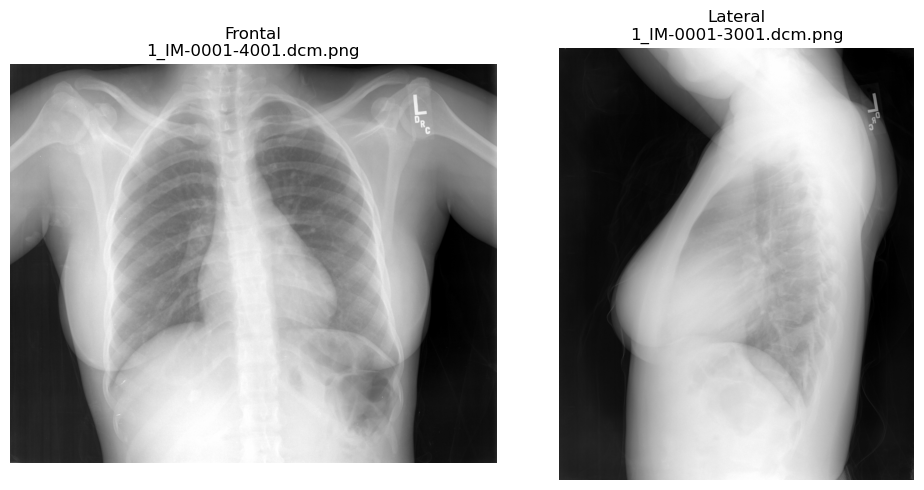


Sample 2
UID: 2
Problems: cardiomegaly;pulmonary artery
Findings: borderline cardiomegaly. midline sternotomy . enlarged pulmonary arteries. clear lungs. inferior .
Impression: no acute pulmonary findings.
problems_multihot [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


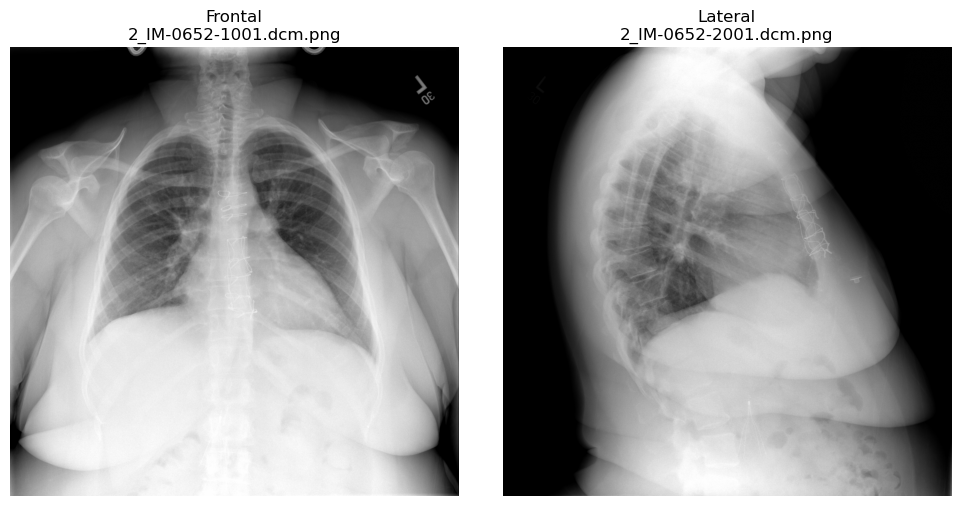


Sample 3
UID: 4
Problems: pulmonary disease, chronic obstructive;bullous emphysema;pulmonary fibrosis;cicatrix;opacity;opacity;opacity;opacity
Findings: there are diffuse bilateral interstitial and alveolar opacities consistent with chronic obstructive lung disease and bullous emphysema. there are irregular opacities in the left lung apex, that could represent a cavitary lesion in the left lung apex.there are streaky opacities in the right upper lobe, scarring. the cardiomediastinal silhouette is normal in size and contour. there is no pneumothorax or large pleural effusion.
Impression: 1. bullous emphysema and interstitial fibrosis. 2. probably scarring in the left apex, although difficult to exclude a cavitary lesion. 3. opacities in the bilateral upper lobes could represent scarring, however the absence of comparison exam, recommend short interval followup radiograph or ct thorax to document resolution.
problems_multihot [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 

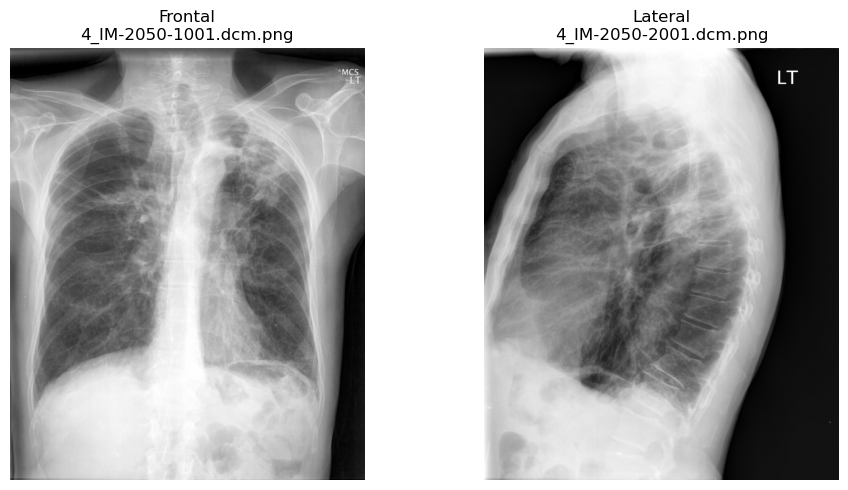

In [62]:
import matplotlib.pyplot as plt
from PIL import Image

# preview rows with images
n_samples = min(3, len(master_df))

for i in range(n_samples):
    row = master_df.iloc[i]
    
    print(f"\nSample {i+1}")
    print("UID:", row["uid"])
    
    if "problems_clean" in master_df.columns:
        print("Problems:", row["problems_clean"])
    if "findings_clean" in master_df.columns:
        print("Findings:", row["findings_clean"])
    if "impression_clean" in master_df.columns:
        print("Impression:", row["impression_clean"])
    if "problems_multihot" in master_df.columns:
        print("problems_multihot", row["problems_multihot"] )
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # frontal image
    frontal_img = Image.open(row["frontal_path"]).convert("L")
    axes[0].imshow(frontal_img, cmap="gray")
    axes[0].set_title(f"Frontal\n{row['frontal_filename']}")
    axes[0].axis("off")
    
    # lateral image
    lateral_img = Image.open(row["lateral_path"]).convert("L")
    axes[1].imshow(lateral_img, cmap="gray")
    axes[1].set_title(f"Lateral\n{row['lateral_filename']}")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

In [65]:
print("Train rows:", len(train_df))
print("Non-null findings_clean:", train_df["findings_clean"].notna().sum())
print("Non-null impression_clean:", train_df["impression_clean"].notna().sum())

print("\nSample findings_clean:")
print(train_df["findings_clean"].head(3).tolist())

Train rows: 2060
Non-null findings_clean: 2060
Non-null impression_clean: 2056

Sample findings_clean:
['both lungs are clear and expanded. an old calcified granuloma is present in the left upper lobe. heart and mediastinum normal.', 'the lungs are clear bilaterally. specifically, no evidence of focal consolidation, pneumothorax, or pleural effusion.. cardio mediastinal silhouette is unremarkable. visualized osseous structures of the thorax are without acute abnormality.', 'stable mild rightward curvature of the thoracic spine. heart size is normal. no focal airspace disease. no pneumothorax or pleural effusion. no acute osseous findings.']


## DATASET FOR PPKED

In [66]:
ppked_train_df = train_df[[
    "uid",
    "frontal_path",
    "findings_clean",
    "problems_list"
]].copy()

# rename columns for clarity
ppked_train_df.columns = ["id", "image_path", "report", "labels"]

print(ppked_train_df.head())
print("\nShape:", ppked_train_df.shape)

     id                                         image_path  \
0   167  /Users/daki/Desktop/NLP/Project/NLU-Project-Wa...   
1  3346  /Users/daki/Desktop/NLP/Project/NLU-Project-Wa...   
2  2361  /Users/daki/Desktop/NLP/Project/NLU-Project-Wa...   
3  3773  /Users/daki/Desktop/NLP/Project/NLU-Project-Wa...   
4   824  /Users/daki/Desktop/NLP/Project/NLU-Project-Wa...   

                                              report  \
0  both lungs are clear and expanded. an old calc...   
1  the lungs are clear bilaterally. specifically,...   
2  stable mild rightward curvature of the thoraci...   
3  the lungs and pleural spaces show no acute abn...   
4  there are no focal areas of consolidation. no ...   

                                          labels  
0                        ['calcified granuloma']  
1                                     ['normal']  
2                                  ['scoliosis']  
3                                     ['normal']  
4  ['calcified granuloma', 'thoraci

In [67]:
ppked_train_df.to_csv("/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/ppked_train.csv", index=False)

print("Saved successfully")

Saved successfully


In [68]:
val_df = pd.read_csv("/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/val.csv")
test_df = pd.read_csv("/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/test.csv")

ppked_val_df = val_df[["uid", "frontal_path", "findings_clean", "problems_list"]].copy()
ppked_val_df.columns = ["id", "image_path", "report", "labels"]

ppked_test_df = test_df[["uid", "frontal_path", "findings_clean", "problems_list"]].copy()
ppked_test_df.columns = ["id", "image_path", "report", "labels"]

print("val shape:", ppked_val_df.shape)
print("test shape:", ppked_test_df.shape)

val shape: (441, 4)
test shape: (442, 4)


In [70]:
ppked_val_df.to_csv("/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/ppked_val.csv", index=False)
ppked_test_df.to_csv("/Users/daki/Desktop/NLP/Project/NLU-Project-Wave2Vec/dataset/processed/ppked_test.csv", index=False)

print("Saved ppked_val.csv and ppked_test.csv")

Saved ppked_val.csv and ppked_test.csv


## Convert csv to json

In [72]:
import json

def convert_df(df, split_name):
    data = []
    for _, row in df.iterrows():
        item = {
            "id": str(row["id"]),
            "report": str(row["report"]),
            "region_size": "4480",  # keep same as repo
            "split": split_name
        }
        data.append(item)
    return data

final_json = {
    "train": convert_df(ppked_train_df, "train"),
    "val": convert_df(ppked_val_df, "val"),
    "test": convert_df(ppked_test_df, "test")
}

with open("/Users/daki/Desktop/NLP/Project/HC-Gen/annotations/iu_xray_custom.json", "w") as f:
    json.dump(final_json, f)

print("JSON created!")

JSON created!


In [73]:
final_json = {
    "train": convert_df(ppked_train_df, "train"),
    "val": convert_df(ppked_val_df, "val"),
    "test": convert_df(ppked_test_df, "test")
}

# Changing the extensions to .h5

In [74]:
import os
import ast
import h5py
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm import tqdm

# Paths
project_root = Path("/Users/daki/Desktop/NLP/Project")
hcgen_root = project_root / "HC-Gen"
processed_dir = project_root / "NLU-Project-Wave2Vec" / "dataset" / "processed"

patch_dir = project_root / "lung_patch_dino"
region_dir = project_root / "lung_region_dino"
patch_dir.mkdir(parents=True, exist_ok=True)
region_dir.mkdir(parents=True, exist_ok=True)

# Load the already prepared PPKED-compatible CSVs
train_df = pd.read_csv(processed_dir / "ppked_train.csv")
val_df = pd.read_csv(processed_dir / "ppked_val.csv")
test_df = pd.read_csv(processed_dir / "ppked_test.csv")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True).drop_duplicates(subset=["id"])

print("Total unique images:", len(all_df))

def load_image_gray(path):
    img = Image.open(path).convert("L")
    return img

def image_to_patch_features(img, grid=4, feat_size=32):
    """
    Create simple 1024-dim patch features from a 4x4 grid.
    Each patch is resized to 32x32 and flattened -> 1024 dims.
    """
    img = img.resize((224, 224))
    arr = np.array(img, dtype=np.float32) / 255.0

    patches = []
    coords = []
    cont_index = []

    patch_h = 224 // grid
    patch_w = 224 // grid

    virtual_size = 4480
    step = virtual_size // grid

    for r in range(grid):
        for c in range(grid):
            y0, y1 = r * patch_h, (r + 1) * patch_h
            x0, x1 = c * patch_w, (c + 1) * patch_w
            patch = arr[y0:y1, x0:x1]

            patch_img = Image.fromarray((patch * 255).astype(np.uint8)).resize((feat_size, feat_size))
            feat = np.array(patch_img, dtype=np.float32).reshape(-1) / 255.0  # 1024 dims

            patches.append(feat)
            coords.append([c * step, r * step])
            cont_index.append(0)

    return (
        np.stack(patches).astype(np.float32),
        np.array(coords, dtype=np.int32),
        np.array(cont_index, dtype=np.int32)
    )

def image_to_region_features(img, feat_size=32):
    """
    Create one global region feature of size 1024.
    """
    img = img.resize((feat_size, feat_size))
    feat = np.array(img, dtype=np.float32).reshape(-1) / 255.0  # 1024 dims

    features = np.expand_dims(feat.astype(np.float32), axis=0)
    coords = np.array([[0, 0]], dtype=np.int32)
    cont_index = np.array([0], dtype=np.int32)

    return features, coords, cont_index

def save_h5(path, features, coords, cont_index):
    with h5py.File(path, "w") as f:
        f.create_dataset("features", data=features)
        f.create_dataset("coords", data=coords)
        f.create_dataset("cont_index", data=cont_index)

errors = []

for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    image_id = str(row["id"])
    image_path = str(row["image_path"])

    patch_path = patch_dir / f"{image_id}.h5"
    region_path = region_dir / f"{image_id}.h5"

    if patch_path.exists() and region_path.exists():
        continue

    try:
        img = load_image_gray(image_path)

        patch_features, patch_coords, patch_types = image_to_patch_features(img, grid=4, feat_size=32)
        region_features, region_coords, region_types = image_to_region_features(img, feat_size=32)

        save_h5(patch_path, patch_features, patch_coords, patch_types)
        save_h5(region_path, region_features, region_coords, region_types)

    except Exception as e:
        errors.append((image_id, image_path, str(e)))

print("Done creating .h5 files")
print("Patch files:", len(list(patch_dir.glob("*.h5"))))
print("Region files:", len(list(region_dir.glob("*.h5"))))
print("Errors:", len(errors))

if errors:
    print(errors[:10])

Total unique images: 2943


100%|██████████████████████████████████████████████████████████████████████████████████████████| 2943/2943 [01:27<00:00, 33.80it/s]

Done creating .h5 files
Patch files: 2943
Region files: 2943
Errors: 0
